# Retrieve chembl data

The purpose of this notebook is to retrieve all compounds on Chembl with measured affinity against the CYP isoform 3A4.

In [2]:
from pathlib import Path
import pathlib
import csv

import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.notebook import tqdm

Protein and data variables.

In [ ]:
readout = 'cyp_3a4'

In [4]:
# define paths
HERE = Path(pathlib.Path.cwd())
DATA = HERE / f"data_{readout}"
DATA.mkdir(parents=True, exist_ok=True)

### Download ligands and bioactivity data from Chembl.

In [5]:
from chembl_webresource_client.new_client import new_client
from tqdm.notebook import tqdm
import concurrent.futures

/home/corey/miniconda3/envs/docking_md/lib/python3.11/site-packages/chembl_webresource_client/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __version__ = __import__('pkg_resources').get_distribution('chembl_webresource_client').version


In [7]:
target = new_client.target
cyp3a4_target = target.search("CYP3A4")[0]
print(cyp3a4_target['target_chembl_id'])

CHEMBL340


In [8]:
cyp_readouts = ['IC50']
all_activities = []

print("Fetching activities for CYP3A4...")

for cyp_readout in cyp_readouts:
    activities = tqdm(new_client.activity.filter(
        standard_type=cyp_readout,
        relation='=',
        target_chembl_id=cyp3a4_target['target_chembl_id']
    ).only(
        "activity_id",
        "assay_chembl_id",
        "molecule_chembl_id",
        "standard_type",
        "standard_units",
        "relation",
        "standard_value",
        "target_chembl_id",
    ))
    all_activities.extend(activities)

print(f"Total CYP3A4 activities fetched: {len(all_activities)}")


Fetching activities for CYP3A4...


  0%|          | 0/6086 [00:00<?, ?it/s]

Total CYP3A4 activities fetched: 6086


In [9]:
########## 2. Helper to use the fetched Chembl records to query for all relevant data associated with them ##########

def process_activity(act):
    record = {
        "activity_id": act.get("activity_id"),
        "assay_chembl_id": act.get("assay_chembl_id"),
        "molecule_chembl_id": act.get("molecule_chembl_id"),
        "type": act.get("standard_type"),
        "standard_units": act.get("standard_units"),
        "relation": act.get("relation"),
        "standard_value": act.get("standard_value"),
        "target_chembl_id": act.get("target_chembl_id"),
        "target_organism": None,
        "assay_description": None,
        "assay_type": None,
        "smiles": None
    }

    try:
        assay = new_client.assay.get(act["assay_chembl_id"])
        record["assay_description"] = assay.get("description")
        record["assay_type"] = assay.get("assay_type")

        molecule = new_client.molecule.get(act["molecule_chembl_id"])
        if molecule and molecule.get("molecule_structures"):
            record["smiles"] = molecule["molecule_structures"].get("canonical_smiles")

        if act.get("target_chembl_id"):
            target = new_client.target.get(act["target_chembl_id"])
            record["target_organism"] = target.get("organism")

    except Exception as e:
        record["error"] = str(e)

    return record


In [10]:
########## 3. Code to run the query in parallel ##########

results = []
max_workers = 20

print("Processing records...")

def init_worker_cache():
    import requests_cache
    requests_cache.install_cache('chembl_cache', backend='sqlite', expire_after=7*24*60*60)

with concurrent.futures.ProcessPoolExecutor(max_workers=max_workers, initializer=init_worker_cache) as executor:
    results = list(tqdm(executor.map(process_activity, all_activities), total=len(all_activities)))


print("Done!")


Processing records...


  0%|          | 0/6086 [00:00<?, ?it/s]

Done!


In [11]:
len(results)

6086

In [12]:
# Because we queried more than one LogD readout, we need to de-duplicate.

unique_activities = list({a["activity_id"]: a for a in results}.values())

In [13]:
# Check distribution of CYP affinities

df = pd.DataFrame(unique_activities)
df['standard_value'] = df['standard_value'].astype(float)

/tmp/ipykernel_56596/1747405060.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate x labels
/tmp/ipykernel_56596/1747405060.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate x labels


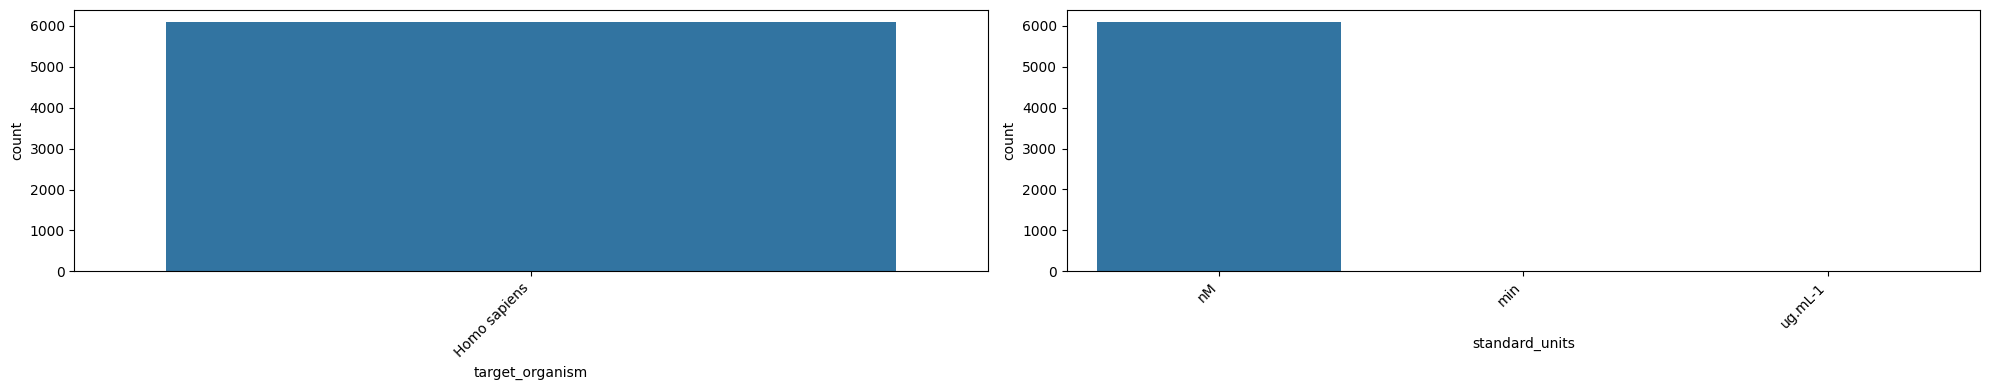

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ["target_organism", "standard_units"]
f, axs = plt.subplots(1, len(cols), figsize=(20, 4))

for ax, col in zip(axs, cols):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate x labels

f.tight_layout()

Keep only those with nM units and non-zero.

In [40]:
filtered_df = df[df['standard_units'] == 'nM']
filtered_df = filtered_df[filtered_df['standard_value'] != 0]
len(filtered_df)

6081

Convert to pIC50.

In [41]:
import math

def ic50_to_pic50(ic50_nM):
    """
    Convert IC50 in nanomolar (nM) to pIC50.
    
    pIC50 = -log10(IC50 in molar)
          = -log10(IC50 in nM * 1e-9)

    Parameters:
        ic50_nM (float): IC50 value in nanomolar

    Returns:
        float: pIC50 value
    """
    if ic50_nM <= 0:
        print(ic50_nM)
        raise ValueError("IC50 must be a positive number")
    
    return -math.log10(ic50_nM * 1e-9)

In [42]:
filtered_df['pIC50'] = filtered_df['standard_value'].apply(lambda x: ic50_to_pic50(x))

<Axes: xlabel='pIC50', ylabel='Count'>

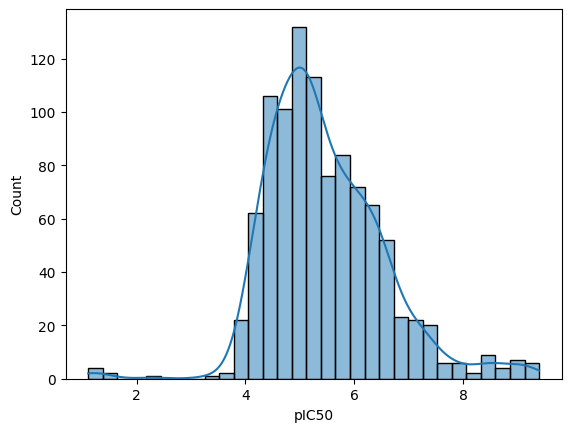

In [43]:
sns.histplot(data=filtered_df.head(1000), x="pIC50", kde=True)

In [44]:
# Dump to file.

filtered_df.to_csv(DATA / f"{readout}_chembl.csv")